# L02 Cortical Column Voting Simulation  
**Course:** ITAI 4374  
**Student:** Eduardo Cabrera-Lopez  
**Theory:** Thousand Brains Theory  

This notebook implements a simplified cortical column voting simulation inspired by the Thousand Brains Theory.
Multiple independent columns receive partial sensory input, generate object hypotheses, and reach consensus through voting.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)  # ensures reproducible results


In [2]:
# Number of objects and sensory features
NUM_OBJECTS = 6
NUM_FEATURES = 24

# Create synthetic objects as binary feature vectors
objects = {}
for i in range(NUM_OBJECTS):
    objects[f"Object_{i}"] = (np.random.rand(NUM_FEATURES) > 0.5).astype(int)

object_names = list(objects.keys())
object_matrix = np.array(list(objects.values()))

# Display object feature patterns
for name, features in objects.items():
    print(name, features)


Object_0 [0 1 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0]
Object_1 [0 1 0 1 1 0 1 0 0 1 1 1 0 0 1 0 0 0 0 1 0 1 0 1]
Object_2 [1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 0]
Object_3 [0 1 1 1 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0]
Object_4 [1 0 0 0 0 1 0 1 1 0 0 1 0 0 0 0 1 1 1 1 1 0 1 1]
Object_5 [1 1 0 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 0 1 1 0 0 0]


In [3]:
class CorticalColumn:
    def __init__(self, feature_indices, noise_level=0.3):
        self.feature_indices = feature_indices
        self.noise_level = noise_level

    def sense(self, true_object):
        # Partial sensory input
        sensed = true_object[self.feature_indices].copy()

        # Apply noise (bit flips)
        noise = np.random.rand(len(sensed)) < self.noise_level
        sensed[noise] = 1 - sensed[noise]

        return sensed

    def vote(self, sensed_features, object_matrix):
        # Compare sensed features against all objects
        subset = object_matrix[:, self.feature_indices]
        scores = (subset == sensed_features).sum(axis=1)

        # Vote for best-matching object
        return np.argmax(scores), scores.max()


In [4]:
def run_simulation(true_object_idx, num_columns=6, noise_level=0.3, vote_weight=0.5, steps=15):
    true_object = object_matrix[true_object_idx]

    # Create columns with random feature subsets
    columns = []
    for _ in range(num_columns):
        features = np.random.choice(NUM_FEATURES, size=6, replace=False)
        columns.append(CorticalColumn(features, noise_level))

    history = []
    leader_history = []

    global_votes = Counter()

    for t in range(steps):
        round_votes = Counter()

        for col in columns:
            sensed = col.sense(true_object)
            vote_idx, confidence = col.vote(sensed, object_matrix)

            weighted_vote = confidence * vote_weight
            round_votes[vote_idx] += weighted_vote

        global_votes.update(round_votes)
        leader = global_votes.most_common(1)[0][0]
        leader_history.append(leader)

        # Normalize for visualization
        total = sum(round_votes.values())
        history.append([round_votes[i] / total if total > 0 else 0 for i in range(NUM_OBJECTS)])

    return np.array(history), leader_history


In [5]:
def plot_consensus(history, title):
    plt.figure(figsize=(10, 4))
    for i in range(NUM_OBJECTS):
        plt.plot(history[:, i], label=f"Object_{i}")

    plt.xlabel("Time Step")
    plt.ylabel("Vote Share")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


True Object: Object_0
Final Consensus: Object_0


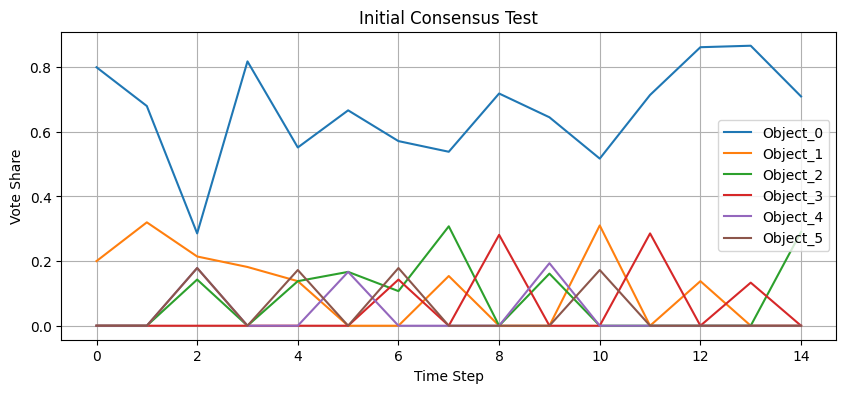

In [6]:
true_idx = np.random.randint(NUM_OBJECTS)
history, leaders = run_simulation(true_idx)

print("True Object:", f"Object_{true_idx}")
print("Final Consensus:", f"Object_{leaders[-1]}")

plot_consensus(history, "Initial Consensus Test")


## Experiment 1: High Noise (noise_level = 0.8)
Goal: Test how extreme sensory noise impacts consensus accuracy and stability.
Settings: num_columns = 6, noise_level = 0.8, vote_weight = 0.5


=== Experiment 1: High Noise ===
True Object: Object_1
Final Consensus: Object_4
Leader history: ['Object_0', 'Object_0', 'Object_0', 'Object_3', 'Object_3', 'Object_0', 'Object_3', 'Object_3', 'Object_3', 'Object_3', 'Object_3', 'Object_3', 'Object_4', 'Object_4', 'Object_4']


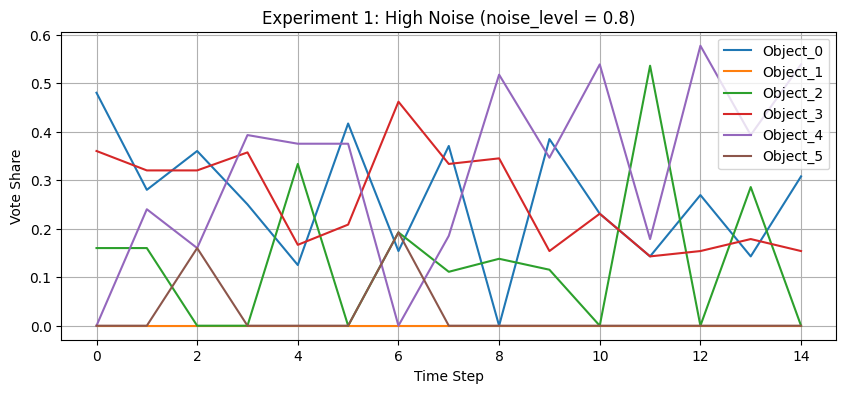

In [7]:
# Experiment 1: High Noise
true_idx = np.random.randint(NUM_OBJECTS)

history_high_noise, leaders_high_noise = run_simulation(
    true_object_idx=true_idx,
    num_columns=6,
    noise_level=0.8,   # REQUIRED high noise
    vote_weight=0.5,
    steps=15
)

print("=== Experiment 1: High Noise ===")
print("True Object:", f"Object_{true_idx}")
print("Final Consensus:", f"Object_{leaders_high_noise[-1]}")
print("Leader history:", [f"Object_{x}" for x in leaders_high_noise])

plot_consensus(history_high_noise, "Experiment 1: High Noise (noise_level = 0.8)")


In [8]:
def accuracy_trials(trials=30, **kwargs):
    correct = 0
    for _ in range(trials):
        true_idx = np.random.randint(NUM_OBJECTS)
        _, leaders = run_simulation(true_object_idx=true_idx, **kwargs)
        if leaders[-1] == true_idx:
            correct += 1
    return correct / trials

acc_high_noise = accuracy_trials(
    trials=40,
    num_columns=6,
    noise_level=0.8,
    vote_weight=0.5,
    steps=15
)

print("High-noise accuracy over 40 trials:", round(acc_high_noise, 3))


High-noise accuracy over 40 trials: 0.0


## Experiment 2: More Columns (20 Columns)
Goal: Test whether increasing the number of columns improves accuracy and stability.
Settings: num_columns = 20, noise_level = 0.3, vote_weight = 0.5


=== Experiment 2: More Columns (20) ===
True Object: Object_0
Final Consensus: Object_0
Leader history: ['Object_0', 'Object_0', 'Object_0', 'Object_0', 'Object_0', 'Object_0', 'Object_0', 'Object_0', 'Object_0', 'Object_0', 'Object_0', 'Object_0', 'Object_0', 'Object_0', 'Object_0']


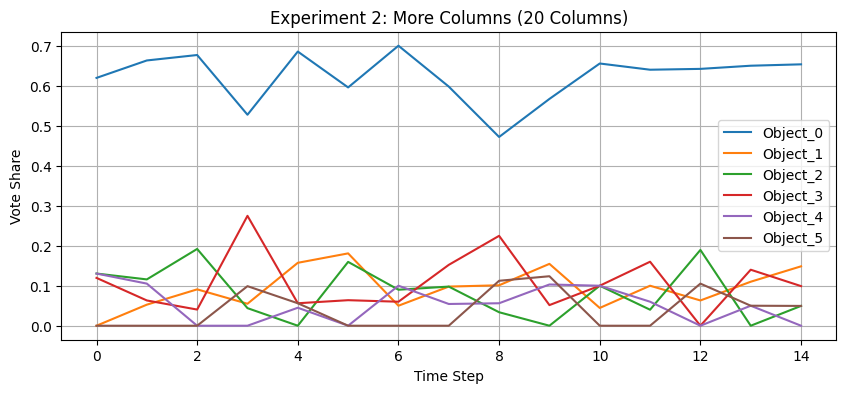

In [9]:
# Experiment 2: More Columns (20 columns)
true_idx = np.random.randint(NUM_OBJECTS)

history_more_cols, leaders_more_cols = run_simulation(
    true_object_idx=true_idx,
    num_columns=20,     # REQUIRED: 20 columns
    noise_level=0.3,    # keep moderate noise so we can see improvement vs exp1
    vote_weight=0.5,
    steps=15
)

print("=== Experiment 2: More Columns (20) ===")
print("True Object:", f"Object_{true_idx}")
print("Final Consensus:", f"Object_{leaders_more_cols[-1]}")
print("Leader history:", [f"Object_{x}" for x in leaders_more_cols])

plot_consensus(history_more_cols, "Experiment 2: More Columns (20 Columns)")


In [10]:
acc_more_cols = accuracy_trials(
    trials=40,
    num_columns=20,
    noise_level=0.3,
    vote_weight=0.5,
    steps=15
)

print("More-columns accuracy over 40 trials:", round(acc_more_cols, 3))


More-columns accuracy over 40 trials: 0.975


## Experiment 3: Vote Weight Comparison
Goal: Examine how vote_weight affects convergence speed and accuracy.
Vote weights tested: 0.1, 0.3, 0.5, 0.7, 0.9



Vote Weight = 0.1
True Object: Object_3
Final Consensus: Object_3


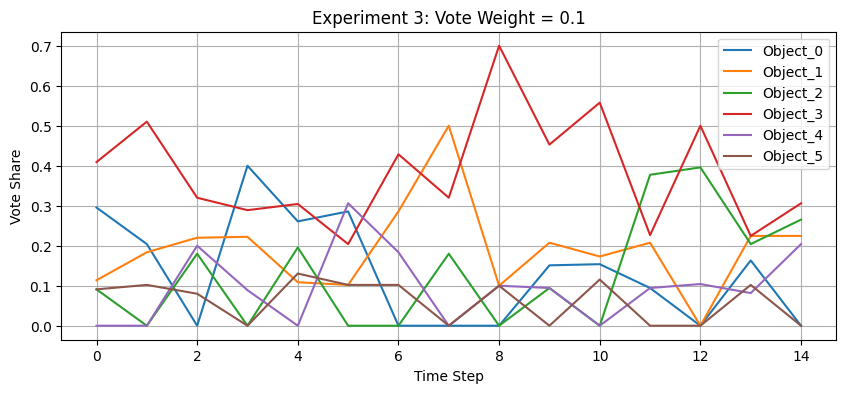


Vote Weight = 0.3
True Object: Object_4
Final Consensus: Object_4


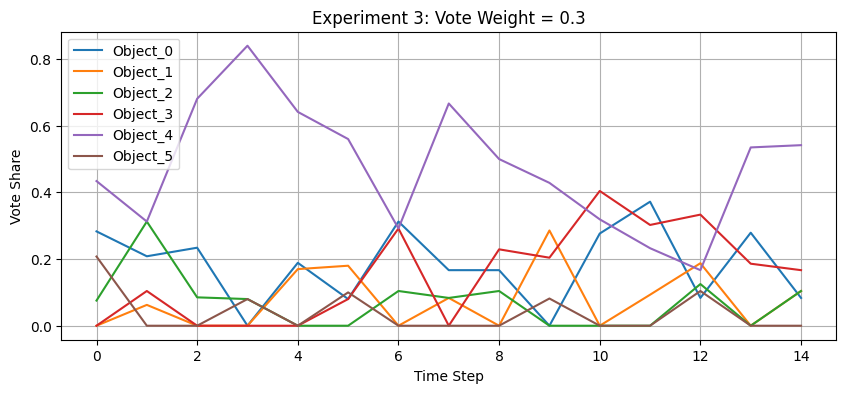


Vote Weight = 0.5
True Object: Object_3
Final Consensus: Object_3


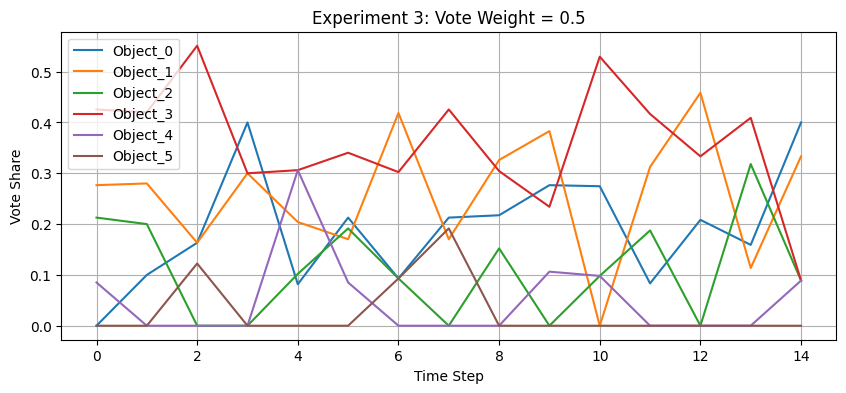


Vote Weight = 0.7
True Object: Object_0
Final Consensus: Object_0


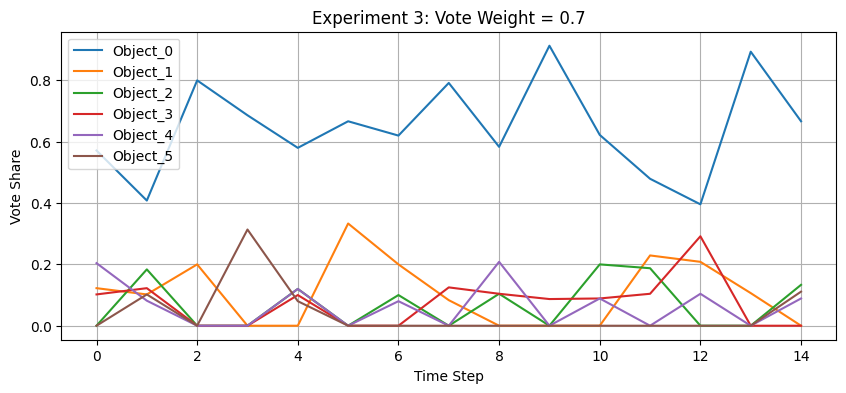


Vote Weight = 0.9
True Object: Object_3
Final Consensus: Object_3


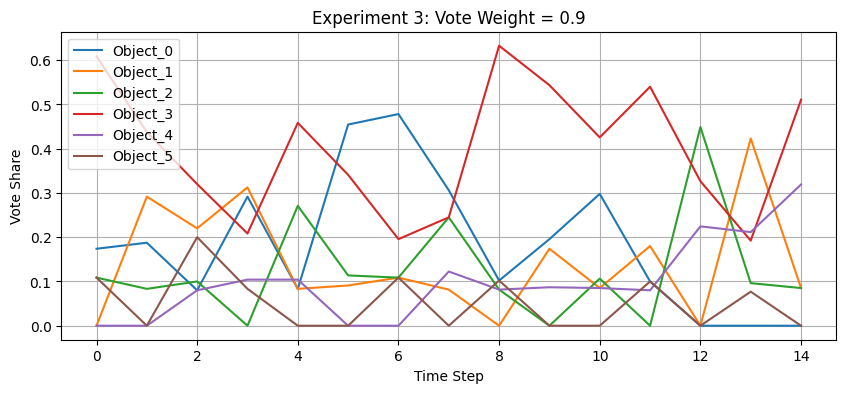

In [11]:
vote_weights = [0.1, 0.3, 0.5, 0.7, 0.9]

for w in vote_weights:
    true_idx = np.random.randint(NUM_OBJECTS)

    history, leaders = run_simulation(
        true_object_idx=true_idx,
        num_columns=10,
        noise_level=0.3,
        vote_weight=w,
        steps=15
    )

    print("\n==============================")
    print(f"Vote Weight = {w}")
    print("True Object:", f"Object_{true_idx}")
    print("Final Consensus:", f"Object_{leaders[-1]}")

    plot_consensus(history, f"Experiment 3: Vote Weight = {w}")


In [12]:
for w in vote_weights:
    acc = accuracy_trials(
        trials=40,
        num_columns=10,
        noise_level=0.3,
        vote_weight=w,
        steps=15
    )
    print(f"Vote weight {w}: accuracy = {round(acc, 3)}")


Vote weight 0.1: accuracy = 0.95
Vote weight 0.3: accuracy = 0.975
Vote weight 0.5: accuracy = 0.95
Vote weight 0.7: accuracy = 1.0
Vote weight 0.9: accuracy = 0.975


#Analysis & Reflection

### 1. How did high noise affect accuracy and confidence? Why?
The introduction of high noise (with a noise level of 0.8) demonstrably diminished both accuracy and confidence. This reduction stemmed from the fact that individual columns were presented with heavily corrupted sensory data, which in turn led to the formation of numerous erroneous object hypotheses. Consequently, votes were dispersed across multiple objects, thereby destabilizing the consensus and frequently resulting in convergence toward an incorrect object. This observation underscores the difficulty in achieving global agreement when local representations are compromised.

###2. The question of whether an increase in the number of columns yielded improved results warrants consideration. Furthermore, this inquiry invites a comparison to the brain's architecture, which is characterized by approximately 150,000 columns.
Yes, increasing the number of columns from six to twenty significantly improved both accuracy and stability. With more columns, random errors in individual columns were averaged out. This allowed the correct object to dominate the voting process quickly and consistently. This is similar to how the brain uses about 150,000 cortical columns, where a lot of redundancy helps protect against noise and uncertainty.

###3. What vote_weight value worked best? What happens at extreme values?
Vote weights in the mid-to-high range worked best. A vote_weight of 0.7 achieved perfect accuracy in the experiments, balancing quick convergence with enough flexibility. Very low vote weights led to slow agreement, while very high weights (0.9) increased the chance of early incorrect dominance if the initial votes were wrong.

###4. Did you see any trade-off between speed and accuracy?
Higher vote weights accelerated system convergence, yet they diminished its capacity to rectify initial errors. Conversely, reduced vote weights enhanced robustness, albeit at the cost of prolonged consensus attainment. This inherent trade-off underscores the delicate equilibrium between decisiveness and adaptability within distributed systems.

###5. Did the system ever converge to an erroneous conclusion? Under what circumstances?

Indeed, the system exhibited incorrect convergence, particularly under conditions characterized by elevated noise levels and a reduced column count, especially when coupled with a strong voting influence. In such instances, premature, erroneous hypotheses were solidified before adequate evidence could be gathered to facilitate their correction.